In [1]:
############################ THIS IS THE FILE FOR CONVOLUTION SENSITIVITY ANALYSIS, PLEASE RUN THE CELLS IN ORDER ############################
################### Figure 14  ##########################

##### Importing the required packages #####
using DataFrames
using CSV
using Plots
using ModelingToolkit, OrdinaryDiffEq, LinearAlgebra
using DifferentialEquations
using DataDrivenDiffEq
using DataDrivenSparse
using StatsPlots
using Statistics
using Distributions
using Dates
using DSP
using RecursiveArrayTools
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using OptimizationBBO
using ForwardDiff
using PenaltyFunctions
using Turing
using StableRNGs
using DataInterpolations
using ComponentArrays
using StatsBase

In [9]:
#################### Making the Data #######################################
theme(:bright)

start_training=350
finish_training=680
##### specify the range you want to chop out for projection
split_start=610
split_finish=split_start+28

sol=[]

for aw in [-1.0, -0.5, 0, +0.5, +1.0]
    begin
        raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
        data=Float64.(Matrix(raw_data[:,[2, 3]]))'
        
        s=size(data)[2]
    
        for i in 1:s
            data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
        end
    

        function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
            d=Beta(α, β)
            max=pdf(d, mode(d))
            step=1/(n+2-1)
            steps=collect(0.0:step: 1.0)
            coefs=zeros(length(steps))
            for i in eachindex(coefs)
                coefs[i]=pdf(d,steps[i])/max
            end
            return steps[2:end-1], coefs[2:end-1]
        end

        n=21  #### number of days that infection rate of each patient changes
        vals, cofs=factors(2.5,4.5,n) #### α=2.5 and β=4.5, we can change the curve shape by changing α and β

    
        ###############################  Using convolution to extract the Infectiveness feature ######################

        infectiveness=zeros(size(data)[2],1);
        infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
    
        #smoothing the infectiveness
        for i in eachindex(infectiveness)
            infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
        end

    
        data1=copy(data)
        data1[2,:]=infectiveness
        
        Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
        Min=0
        for i in 1:size(data1)[1]
            for j in 1:size(data1)[2]
                data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
            end
        end 
        
    
        data2=data1[:,start_training:split_start]
        data3=data1[:,split_finish:finish_training]
    
        X1=copy(data2);
        X2=copy(data3);
    end

    ############################# Making control signal ########################
    begin
        v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
        v_data=Matrix{Float64}(v_raw_data[:,3:5])'

    
        ####  weekly averaging
        avg_days=7
        s=size(v_data)
        weekly=Matrix{Float64}(undef,s[1], s[2])
        for i in 1:size(v_data)[1]
            weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
        end

        ############# beta distribution  

        n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
        vvals, vcofs=factors(3+aw,4+aw,n) #### α=4 and β=4, we can change the curve shape by changing α and β



        ###############################  Using convolution to extract the Antibody feature ######################
        dose1=zeros(size(v_data)[2],1);
        dose2=zeros(size(v_data)[2],1);
        dose3=zeros(size(v_data)[2],1);

        vcofs1=reverse(reverse(vcofs))
        for i in 1:lastindex(dose1)
            for j in 1:min(n,i)-1
                dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
                dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
                dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
            end 
        end

        dose11=zeros(size(raw_data)[1],1);
        dose21=zeros(size(raw_data)[1],1);
        dose31=zeros(size(raw_data)[1],1);

        difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
        
        for i in difference+1:lastindex(dose11)
            dose11[i]=dose1[i-difference]
            dose21[i]=dose2[i-difference]
            dose31[i]=dose3[i-difference]
        end

        antibody=dose11.+dose21.+ dose31
        
        Max_antibody=maximum(antibody)
        Min=0
        for i in 1:size(antibody)[1]       
            antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
        end
        
        control=vcat(antibody') ### used in prediction
        control1=vcat(antibody[start_training:split_start]');
        control2=vcat(antibody[split_finish:finish_training]');
    end
    ######################## definition and solving of the problem using SINDy algorithm ##################
    begin
        tick=1

        t1=collect(0.0:1/tick:(split_start-start_training)/tick);
        itp_method=InterpolationMethod(LinearInterpolation)

        t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
        
        final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
        sir_problem=ContinuousDataset(final_data)

        @variables u[1:2] c[1:1]
        u = collect(u)
        c = collect(c)

        if start_training==1
            h = Num[polynomial_basis([u; c], 1);]        
        else
            h = Num[polynomial_basis([u; c], 2);]        
        end

        basis = Basis(h, u, controls=c)
        

        ### choosing STLSQ as an optimizer
        ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
        opt = STLSQ(exp10.(-3:0.01:+1))

        options = DataDrivenCommonOptions(maxiters = 1000,                                  
                                    normalize = DataNormalization(ZScoreTransform),
                                    selector = bic, digits = 3)

        ddsol = solve(sir_problem, basis, opt, options=options);
        push!(sol, ddsol)

    end
end

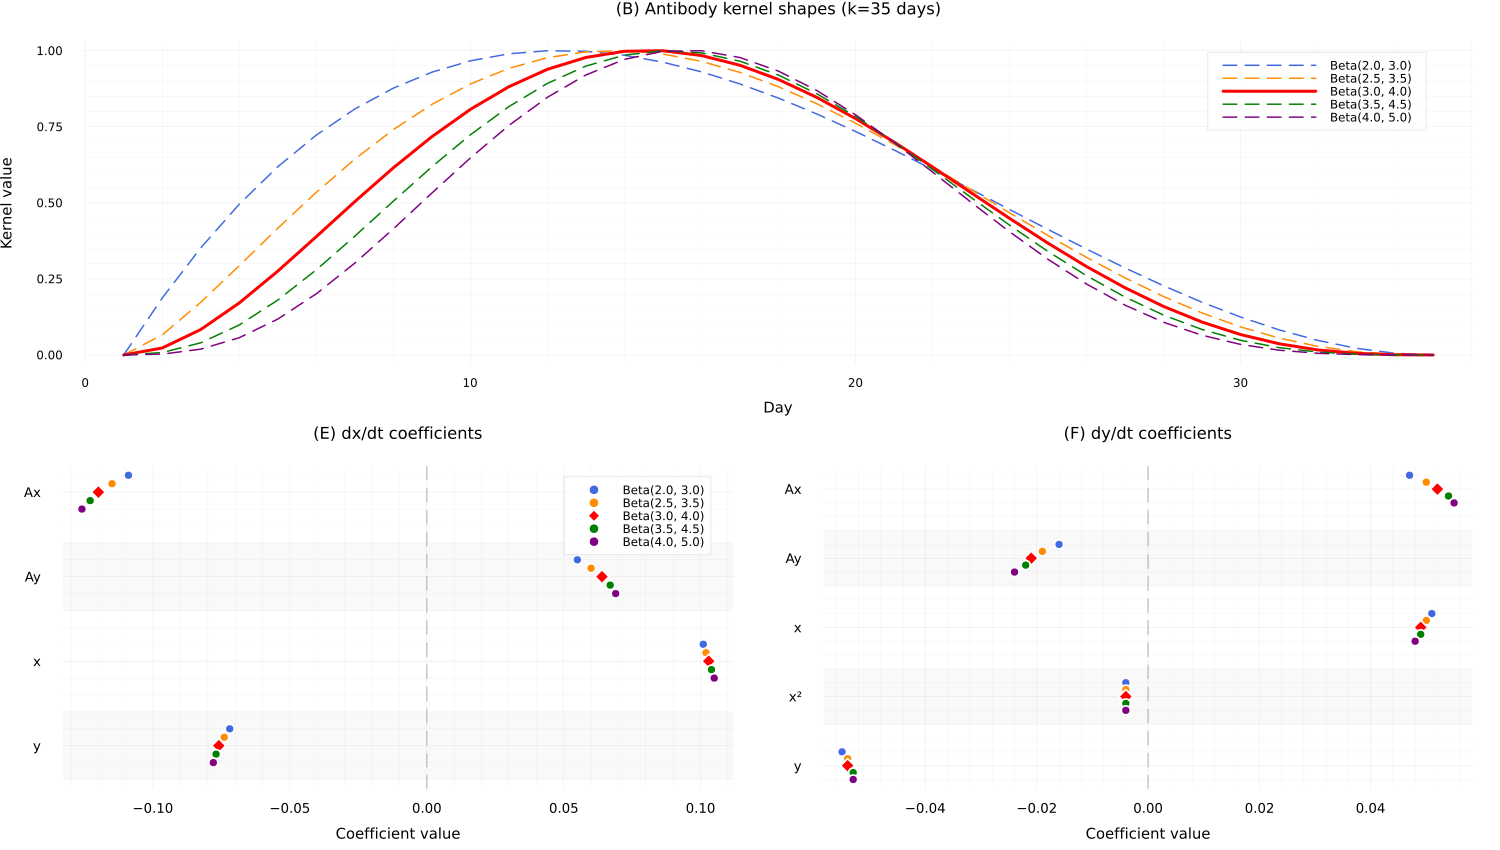

In [3]:
using Plots, DataDrivenDiffEq, Symbolics, Distributions

# ---- Configuration ----
shifts = [-1.0, -0.5, 0.0, +0.5, +1.0]
base_α, base_β = 3.0, 4.0
labels = ["Beta($(base_α+aw), $(base_β+aw))" for aw in shifts]
colors = [:royalblue, :darkorange, :red, :green, :purple]
baseline_idx = 3  # aw=0

# ---- Panel A: Kernel shapes ----
k = 35
kernel_curves = []
for aw in shifts
    d = Beta(base_α + aw, base_β + aw)
    xs = range(0, 1, length=k)
    ys = [pdf(d, x) for x in xs]
    ys ./= maximum(ys)  # normalize to peak=1
    push!(kernel_curves, ys)
end

pA = plot(xlabel="Day", ylabel="Kernel value",
          title="(B) Antibody kernel shapes (k=$k days)",
          legend=:topright, size=(500, 350), 
          titlefontsize=11, guidefontsize=10, legendfontsize=8)

for (i, aw) in enumerate(shifts)
    style = (i == baseline_idx) ? :solid : :dash
    lw = (i == baseline_idx) ? 3 : 1.5
    plot!(pA, 1:k, kernel_curves[i], label=labels[i],
          color=colors[i], linestyle=style, linewidth=lw)
end

# ---- Extract equations and parse coefficients ----
all_eq_strs = Vector{Vector{String}}()
for s in sol
    sys = get_basis(s)
    p_opt = get_parameter_values(sys)
    eqs = equations(sys)
    params_dict = Dict(parameters(sys) .=> p_opt)
    substituted = substitute.(eqs, Ref(params_dict))
    push!(all_eq_strs, string.(substituted))
end

function parse_equation(eq_str)
    rhs = strip(split(eq_str, "~")[2])
    rhs = replace(rhs, " - " => " + -")
    tokens = strip.(split(rhs, "+"))
    filter!(t -> t != "", tokens)
    
    coeffs = Dict{String, Float64}()
    
    function to_readable(term_part)
        t = strip(term_part)
        if startswith(t, "(") && endswith(t, ")")
            t = t[2:end-1]
        end
        t = replace(t, "u[1]" => "x")
        t = replace(t, "u[2]" => "y")
        t = replace(t, "c[1]" => "A")
        t = replace(t, "^2" => "²")
        parts = sort(split(t, "*"))
        return join(parts, "")
    end
    
    for token in tokens
        token = strip(token)
#######################
    # Handle terms like 0.004(u[1]^2)
        m0 = match(r"^([+-]?\d*\.?\d+)\((.+)\)$", token)
        if m0 !== nothing
            coeff = parse(Float64, m0.captures[1])
            term = to_readable(m0.captures[2])
            coeffs[term] = coeff
            continue
        end
#########################

        m = match(r"^([+-]?\d*\.?\d+)\s*\*?\s*(.+)$", token)
        if m !== nothing
            coeff = parse(Float64, m.captures[1])
            term = to_readable(m.captures[2])
            coeffs[term] = coeff
        else
            m2 = match(r"^([+-]?\d+\.?\d*)$", token)
            if m2 !== nothing
                coeffs["const"] = parse(Float64, m2.captures[1])
            else
                if startswith(token, "-")
                    coeffs[to_readable(token[2:end])] = -1.0
                else
                    coeffs[to_readable(token)] = 1.0
                end
            end
        end
    end
    return coeffs
end

parsed = [[parse_equation(eq) for eq in eqs] for eqs in all_eq_strs]

# ---- Panel B: Dot plot for dx/dt and dy/dt ----
eq_names = ["(E) dx/dt coefficients", "(F) dy/dt coefficients"]

dot_plots = []
for eq_idx in 1:2
    all_terms = [Set(keys(parsed[i][eq_idx])) for i in 1:length(sol)]
    common_terms = sort(collect(intersect(all_terms...)))
    
    n_terms = length(common_terms)
    
    p = plot(title=eq_names[eq_idx], xlabel="Coefficient value", 
             yticks=(1:n_terms, common_terms),
             titlefontsize=11, guidefontsize=10, tickfontsize=9,
             legend=(eq_idx == 1 ? :topright : :none),
             size=(500, 350), yflip=true)
    
    vline!(p, [0], color=:gray, linestyle=:dash, label=nothing, alpha=0.5)
    
    # Draw horizontal bands for readability
    for j in 1:n_terms
        if j % 2 == 0
            hspan!(p, [j - 0.4, j + 0.4], color=:gray, alpha=0.05, label=nothing)
        end
    end
    
    # Plot dots
    offsets = [-0.2, -0.1, 0.0, 0.1, 0.2]  # vertical jitter for 5 configs
    for (i, aw) in enumerate(shifts)
        vals = [parsed[i][eq_idx][t] for t in common_terms]
        ys = (1:n_terms) .+ offsets[i]
        
        ms = (i == baseline_idx) ? :diamond : :circle
        msz = (i == baseline_idx) ? 7 : 5
        
        scatter!(p, vals, ys, label=labels[i],
                 color=colors[i], marker=ms, markersize=msz,
                 markerstrokewidth=1, markerstrokecolor=:white)
    end
    
    push!(dot_plots, p)
end

# ---- Combine all panels ----
fig = plot(pA, dot_plots[1], dot_plots[2],
           layout=@layout([a; b c]),
           size=(1500, 850),
           margin=5Plots.mm)

display(fig)

# Save
#savefig(fig, "kernel_sensitivity.png")
#savefig(fig, "kernel_sensitivity.pdf")

In [13]:
#################### Making the Data #######################################
theme(:bright)

start_training=350
finish_training=680
##### specify the range you want to chop out for projection
split_start=610
split_finish=split_start+28

sol=[]

for aw in [-1.0, -0.5, 0, +0.5, +1.0]
    begin
        raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
        data=Float64.(Matrix(raw_data[:,[2, 3]]))'
        
        s=size(data)[2]
    
        for i in 1:s
            data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
        end
    

        function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
            d=Beta(α, β)
            max=pdf(d, mode(d))
            step=1/(n+2-1)
            steps=collect(0.0:step: 1.0)
            coefs=zeros(length(steps))
            for i in eachindex(coefs)
                coefs[i]=pdf(d,steps[i])/max
            end
            return steps[2:end-1], coefs[2:end-1]
        end

        n=21  #### number of days that infection rate of each patient changes
        vals, cofs=factors(2.5+aw,4.5+aw,n) #### α=2.5 and β=4.5, we can change the curve shape by changing α and β

    
        ###############################  Using convolution to extract the Infectiveness feature ######################

        infectiveness=zeros(size(data)[2],1);
        infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
    
        #smoothing the infectiveness
        for i in eachindex(infectiveness)
            infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
        end

    
        data1=copy(data)
        data1[2,:]=infectiveness
        
        Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
        Min=0
        for i in 1:size(data1)[1]
            for j in 1:size(data1)[2]
                data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
            end
        end 
        
    
        data2=data1[:,start_training:split_start]
        data3=data1[:,split_finish:finish_training]
    
        X1=copy(data2);
        X2=copy(data3);
    end

    ############################# Making control signal ########################
    begin
        v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
        v_data=Matrix{Float64}(v_raw_data[:,3:5])'

    
        ####  weekly averaging
        avg_days=7
        s=size(v_data)
        weekly=Matrix{Float64}(undef,s[1], s[2])
        for i in 1:size(v_data)[1]
            weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
        end

        ############# beta distribution  

        n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
        vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β



        ###############################  Using convolution to extract the Antibody feature ######################
        dose1=zeros(size(v_data)[2],1);
        dose2=zeros(size(v_data)[2],1);
        dose3=zeros(size(v_data)[2],1);

        vcofs1=reverse(reverse(vcofs))
        for i in 1:lastindex(dose1)
            for j in 1:min(n,i)-1
                dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
                dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
                dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
            end 
        end

        dose11=zeros(size(raw_data)[1],1);
        dose21=zeros(size(raw_data)[1],1);
        dose31=zeros(size(raw_data)[1],1);

        difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
        
        for i in difference+1:lastindex(dose11)
            dose11[i]=dose1[i-difference]
            dose21[i]=dose2[i-difference]
            dose31[i]=dose3[i-difference]
        end

        antibody=dose11.+dose21.+ dose31
        
        Max_antibody=maximum(antibody)
        Min=0
        for i in 1:size(antibody)[1]       
            antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
        end
        
        control=vcat(antibody') ### used in prediction
        control1=vcat(antibody[start_training:split_start]');
        control2=vcat(antibody[split_finish:finish_training]');
    end
    ######################## definition and solving of the problem using SINDy algorithm ##################
    begin
        tick=1

        t1=collect(0.0:1/tick:(split_start-start_training)/tick);
        itp_method=InterpolationMethod(LinearInterpolation)

        t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
        
        final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
        sir_problem=ContinuousDataset(final_data)

        @variables u[1:2] c[1:1]
        u = collect(u)
        c = collect(c)

        if start_training==1
            h = Num[polynomial_basis([u; c], 1);]        
        else
            h = Num[polynomial_basis([u; c], 2);]        
        end

        basis = Basis(h, u, controls=c)
        

        ### choosing STLSQ as an optimizer
        ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
        opt = STLSQ(exp10.(-3:0.01:+1))

        options = DataDrivenCommonOptions(maxiters = 1000,                                  
                                    normalize = DataNormalization(ZScoreTransform),
                                    selector = bic, digits = 3)

        ddsol = solve(sir_problem, basis, opt, options=options);
        push!(sol, ddsol)
    
    end
end

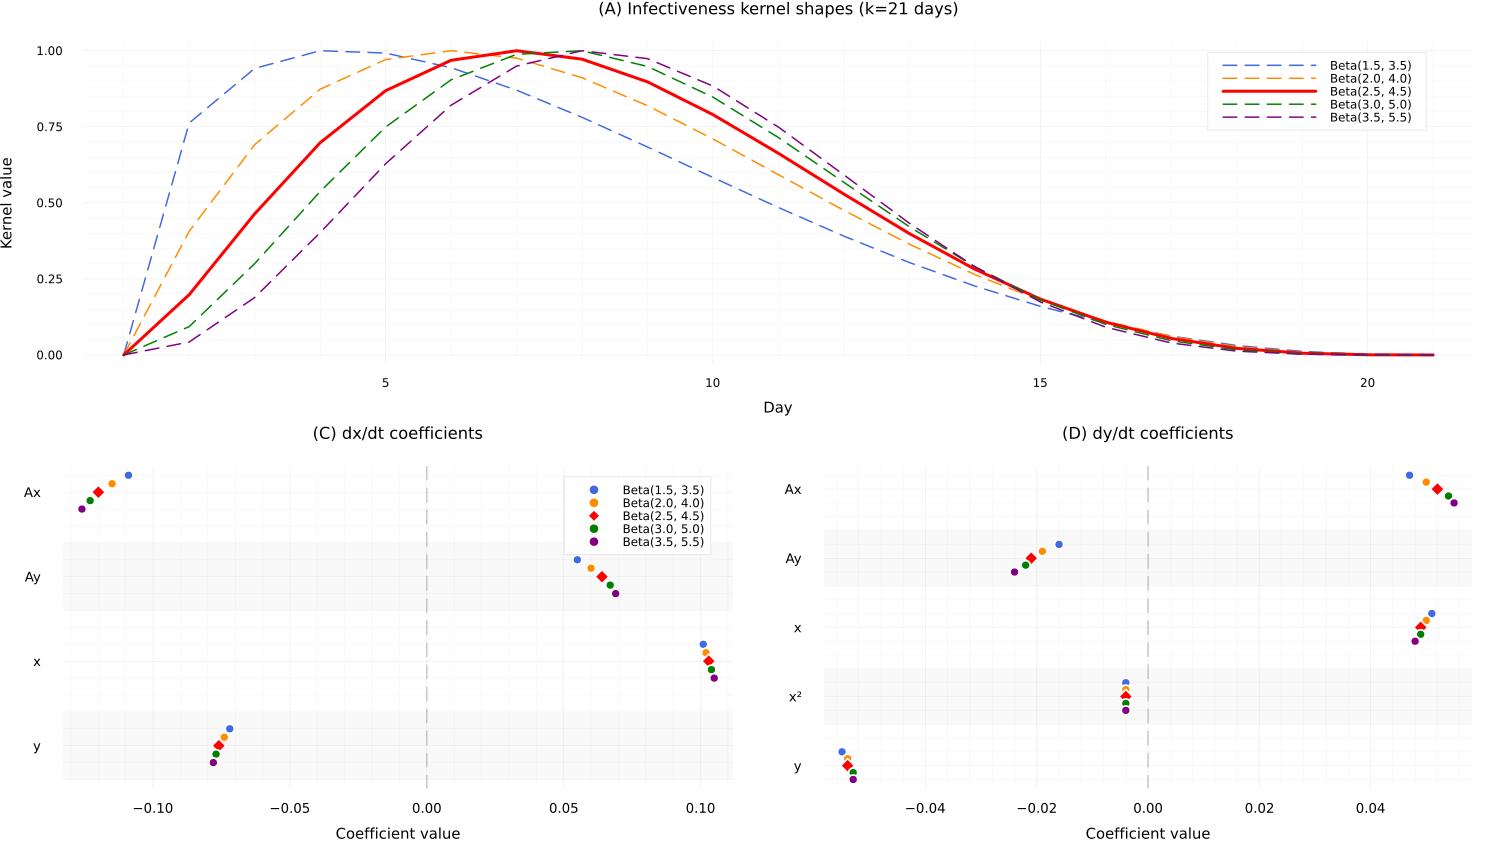

In [10]:
using Plots, DataDrivenDiffEq, Symbolics, Distributions

# ---- Configuration ----
shifts = [-1.0, -0.5, 0.0, +0.5, +1.0]
base_α, base_β = 2.5, 4.5
labels = ["Beta($(base_α + aw), $(base_β + aw))" for aw in shifts]
colors = [:royalblue, :darkorange, :red, :green, :purple]
baseline_idx = 3  # aw = 0

# ---- Panel A: Kernel shapes ----
k = 21
kernel_curves = []

for aw in shifts
    d = Beta(base_α + aw, base_β + aw)
    xs = range(0, 1, length = k)
    ys = [pdf(d, x) for x in xs]
    ys ./= maximum(ys)  # normalize to peak = 1
    push!(kernel_curves, ys)
end

pA = plot(
    xlabel = "Day",
    ylabel = "Kernel value",
    title = "(A) Infectiveness kernel shapes (k=$k days)",
    legend = :topright,
    size = (500, 350),
    titlefontsize = 11,
    guidefontsize = 10,
    legendfontsize = 8
)

for (i, aw) in enumerate(shifts)
    style = (i == baseline_idx) ? :solid : :dash
    lw = (i == baseline_idx) ? 3 : 1.5

    plot!(
        pA,
        1:k,
        kernel_curves[i],
        label = labels[i],
        color = colors[i],
        linestyle = style,
        linewidth = lw
    )
end

# ---- Extract equations and parse coefficients ----
all_eq_strs = Vector{Vector{String}}()

for s in sol
    sys = get_basis(s)
    p_opt = get_parameter_values(sys)
    eqs = equations(sys)

    params_dict = Dict(parameters(sys) .=> p_opt)
    substituted = substitute.(eqs, Ref(params_dict))

    push!(all_eq_strs, string.(substituted))
end

function parse_equation(eq_str)
    rhs = strip(split(eq_str, "~")[2])
    rhs = replace(rhs, " - " => " + -")
    tokens = strip.(split(rhs, "+"))
    filter!(t -> t != "", tokens)

    coeffs = Dict{String, Float64}()

    function to_readable(term_part)
        t = strip(term_part)

        if startswith(t, "(") && endswith(t, ")")
            t = t[2:end-1]
        end

        t = replace(t, "u[1]" => "x")
        t = replace(t, "u[2]" => "y")
        t = replace(t, "c[1]" => "A")
        t = replace(t, "^2" => "²")

        parts = sort(split(t, "*"))
        return join(parts, "")
    end

    for token in tokens
        token = strip(token)

        # Handle terms like 0.004(u[1]^2)
        m0 = match(r"^([+-]?\d*\.?\d+)\((.+)\)$", token)

        if m0 !== nothing
            coeff = parse(Float64, m0.captures[1])
            term = to_readable(m0.captures[2])
            coeffs[term] = coeff
            continue
        end

        # Handle terms like 0.004 * u[1]^2
        m = match(r"^([+-]?\d*\.?\d+)\s*\*?\s*(.+)$", token)

        if m !== nothing
            coeff = parse(Float64, m.captures[1])
            term = to_readable(m.captures[2])
            coeffs[term] = coeff
        else
            # Handle constant terms
            m2 = match(r"^([+-]?\d+\.?\d*)$", token)

            if m2 !== nothing
                coeffs["const"] = parse(Float64, m2.captures[1])
            else
                # Handle terms without explicit coefficient
                if startswith(token, "-")
                    coeffs[to_readable(token[2:end])] = -1.0
                else
                    coeffs[to_readable(token)] = 1.0
                end
            end
        end
    end

    return coeffs
end

parsed = [[parse_equation(eq) for eq in eqs] for eqs in all_eq_strs]

# ---- Panel B: Dot plot for dx/dt and dy/dt ----
eq_names = ["(C) dx/dt coefficients", "(D) dy/dt coefficients"]

dot_plots = []

for eq_idx in 1:2
    all_terms = [Set(keys(parsed[i][eq_idx])) for i in 1:length(sol)]

    # Important correction:
    # Use union instead of intersection, so terms that disappear in one model
    # are still shown. Missing coefficients are plotted as 0.0.
    common_terms = sort(collect(union(all_terms...)))

    n_terms = length(common_terms)

    p = plot(
        title = eq_names[eq_idx],
        xlabel = "Coefficient value",
        yticks = (1:n_terms, common_terms),
        titlefontsize = 11,
        guidefontsize = 10,
        tickfontsize = 9,
        legend = (eq_idx == 1 ? :topright : :none),
        size = (500, 350),
        yflip = true
    )

    vline!(
        p,
        [0],
        color = :gray,
        linestyle = :dash,
        label = nothing,
        alpha = 0.5
    )

    # Draw horizontal bands for readability
    for j in 1:n_terms
        if j % 2 == 0
            hspan!(
                p,
                [j - 0.4, j + 0.4],
                color = :gray,
                alpha = 0.05,
                label = nothing
            )
        end
    end

    # Plot dots
    offsets = [-0.2, -0.1, 0.0, 0.1, 0.2]

    for (i, aw) in enumerate(shifts)
        # Important correction:
        # If a term does not exist in this model, assign coefficient 0.0.
        vals = [get(parsed[i][eq_idx], t, 0.0) for t in common_terms]
        ys = (1:n_terms) .+ offsets[i]

        ms = (i == baseline_idx) ? :diamond : :circle
        msz = (i == baseline_idx) ? 7 : 5

        scatter!(
            p,
            vals,
            ys,
            label = labels[i],
            color = colors[i],
            marker = ms,
            markersize = msz,
            markerstrokewidth = 1,
            markerstrokecolor = :white
        )
    end

    push!(dot_plots, p)
end

# ---- Combine all panels ----
fig1 = plot(
    pA,
    dot_plots[1],
    dot_plots[2],
    layout = @layout([a; b c]),
    size = (1500, 850),
    margin = 5Plots.mm
)

display(fig1)

# Save
# savefig(fig1, "kernel_sensitivity.png")
# savefig(fig1, "kernel_sensitivity.pdf")

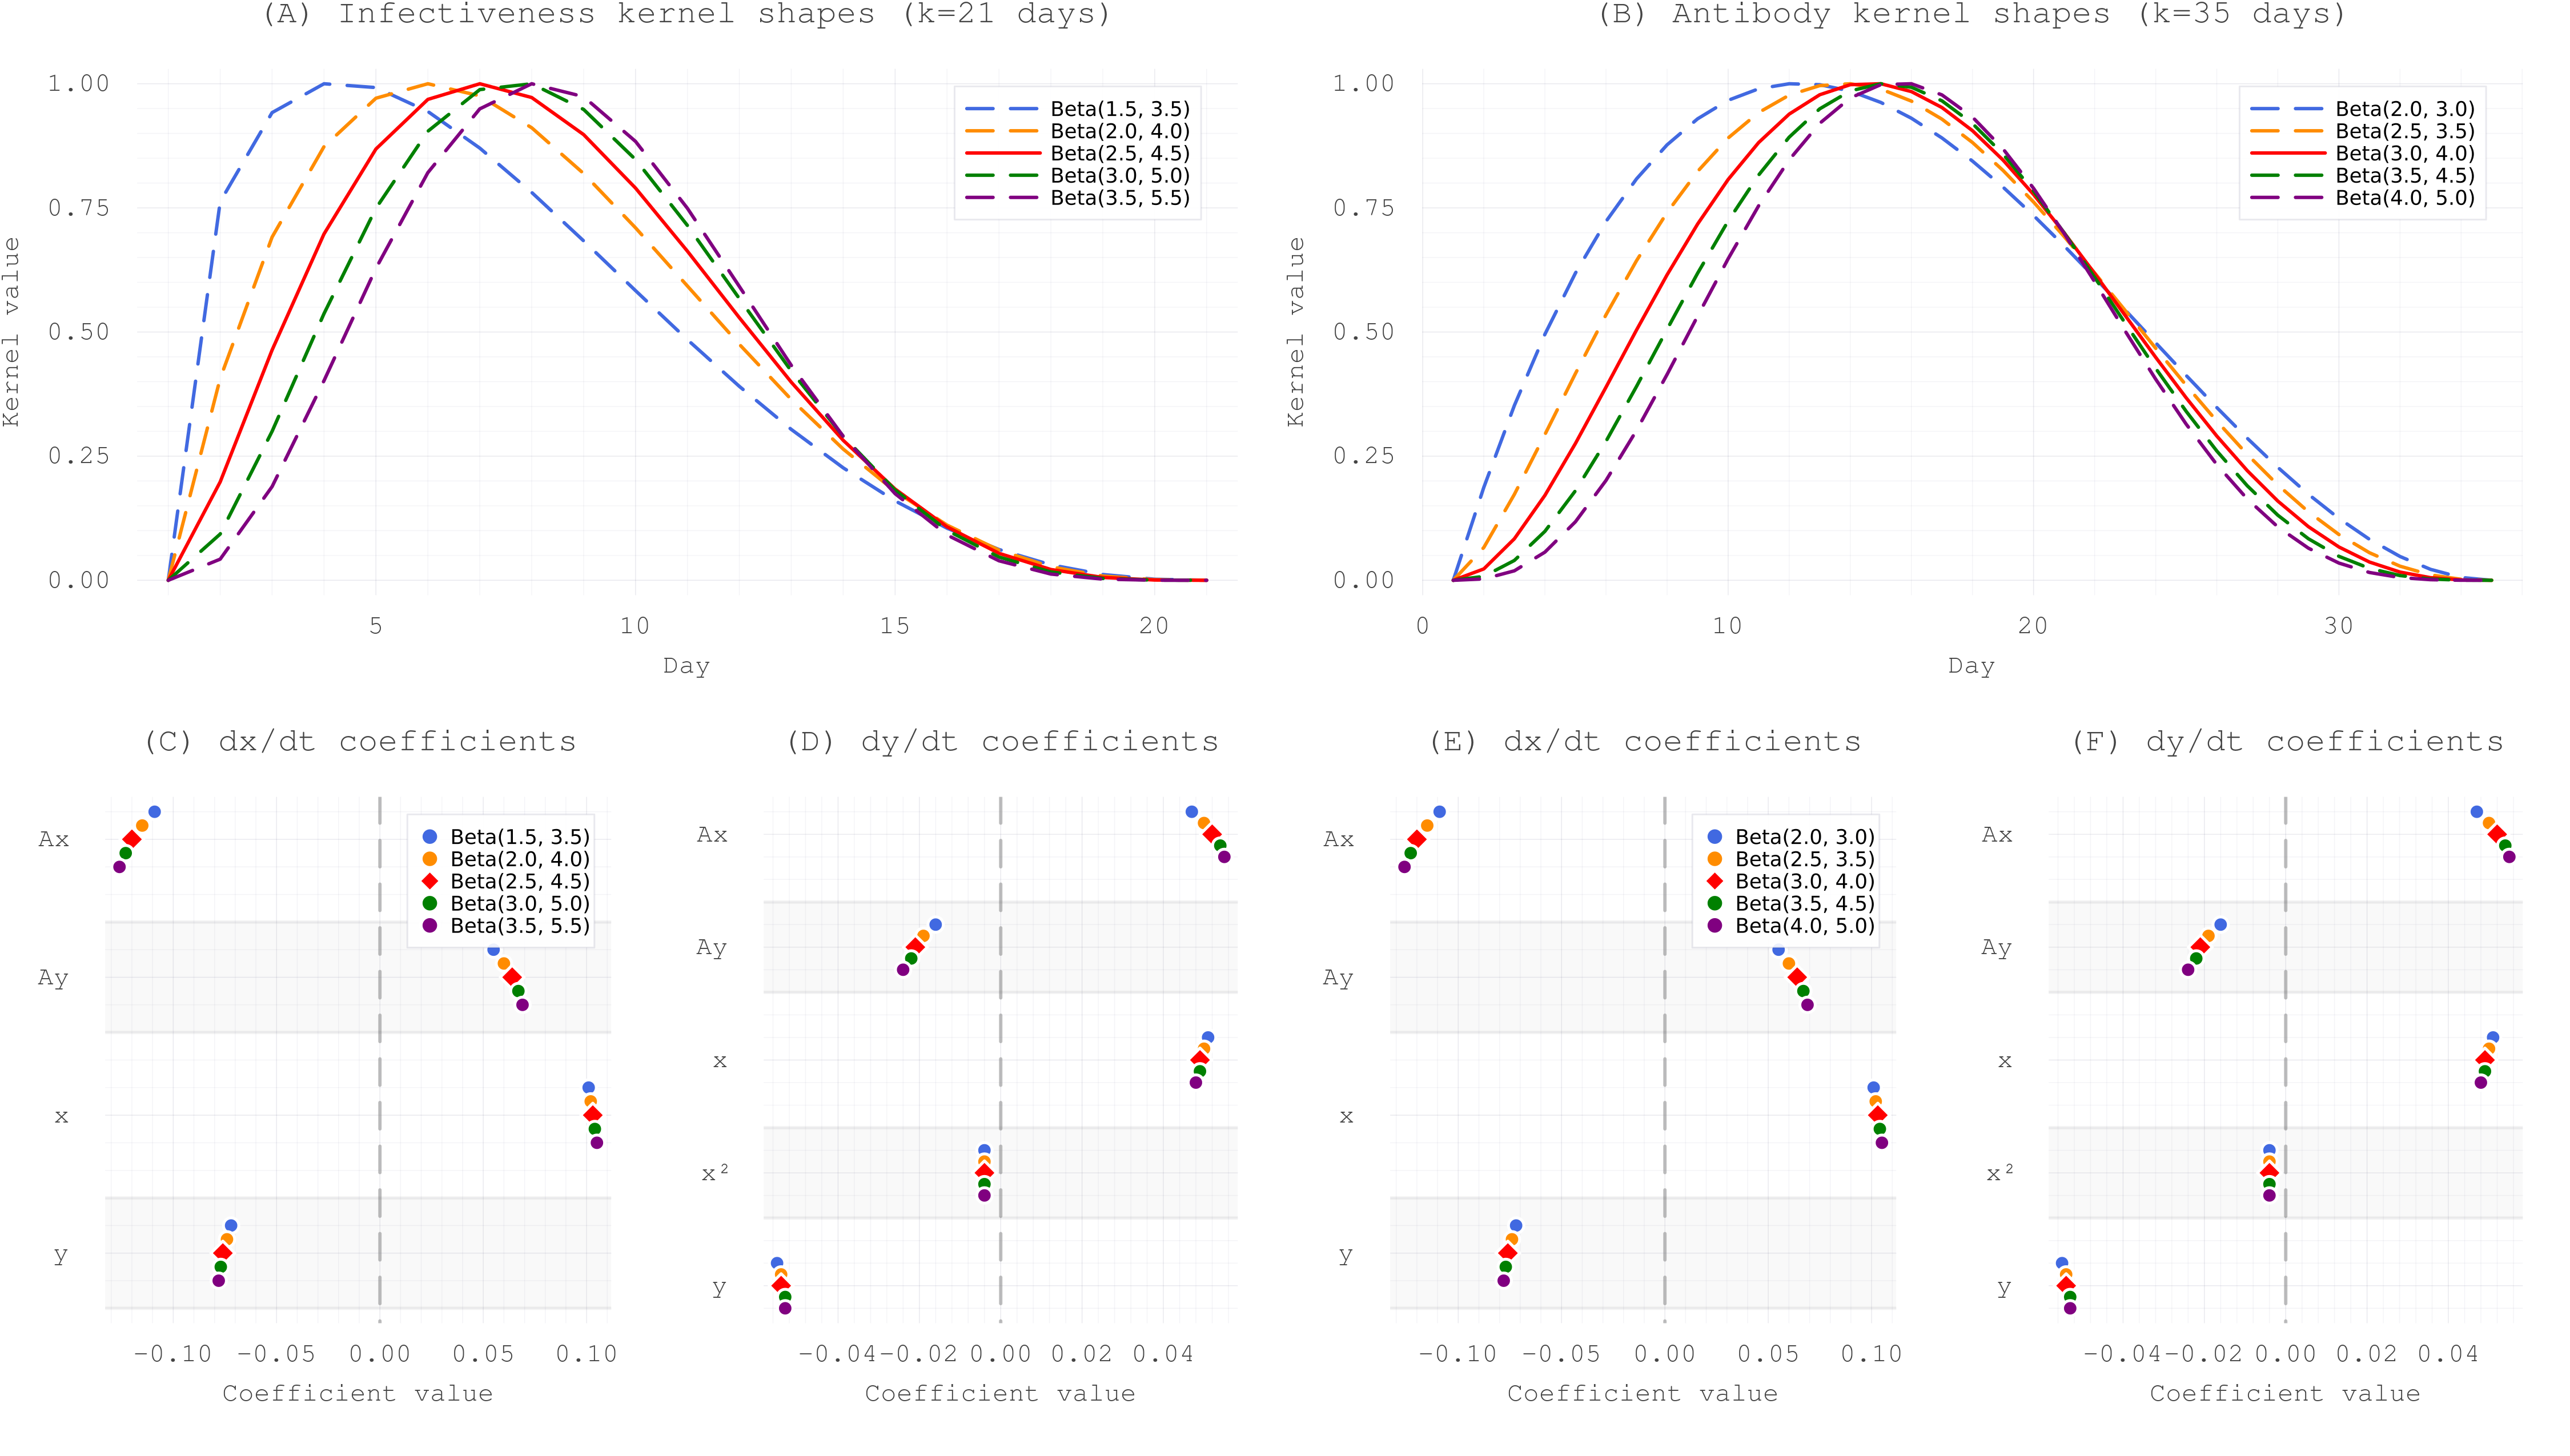

In [11]:
plot(fig1, fig, 
    lw=2, left_margin = 5Plots.mm, bottom_margin = 10Plots.mm, 
    dpi=300, titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
    ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))#, legendfont = font(8, "Arial"))

In [ ]:
#savefig("kernel_sensitivity.png")
